In [1]:
import gurobipy as gp
import math
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import re
import os
import shutil

In [2]:
# output generation for paper 3

In [3]:
# get input paths
test_set = "paper3" # todo update this as needed
instance_fldr = os.path.join("instances", test_set)
test_set_fldr = os.path.join("test_sets", test_set)
results_fldr = os.path.join("results", test_set)
out_fldr = os.path.join("outputs", test_set)

# set filters
seed_idxs = [0]  
max_indices = 2
max_runtime = 1800
degrees = [-1, 1]  # todo update this as needed
term_list = [4, 64]  # todo update this as needed
filter_cbc = False
max_base_std = 1e10
min_termination_time = 0  # todo update this as needed - fitler wins on default runs that took at least 10 seconds
short, medium, long = 60, 600, 1800
remove_status_changes = False
win_threshold = .2
filter_redundant = True

default_generators = ["None"]
test_generators = ["NoDisjunction", "DisjWarmStart"]
generators = default_generators + test_generators
disjunctive_generators = [g for g in generators if g != "None"]
parametric_generators = [g for g in generators if g not in ["None", "New"]]
cut_generators = [g for g in generators if g not in ["None", "DisjWarmStart"]]


# set up some mappings
cat_map_new_lines = {
    "None": "Default",
    "Farkas": "Param Disj,\nParam Cuts",
    "Old": "Param Disj,\nCalc Cuts",
    "New": "Calc Disj,\nCalc Cuts",
    "NoDisjunction": "Cuts Warm Start",
    "DisjWarmStart": "Nodes Warm Start",
}
cat_map = {
    "None": "Default",
    "Farkas": "Param Disj, Param Cuts",
    "Old": "Param Disj, Calc Cuts",
    "New": "Calc Disj, Calc Cuts",
    "NoDisjunction": "Cuts Warm Start",
    "DisjWarmStart": "Nodes Warm Start",
}
perturbation_map = {
    "matrix": "Coefficient Matrix",
    "rhs": "Right Hand Side",
    "objective": "Objective"
}
label = {
    "postRootTime": "Time after Processing Root nodes",
    "rootDualBoundTimeSansVpc": "Root Processing Time (Minus VPC Generation)",
    "terminationTimeSansVpc": "Time (Minus VPC Generation)",
    "terminationTime": "Solve Time",
    "nodes": "Nodes Processed",
    "iterations": "LP Iterations",
}
unit = {
    "postRootTime": "(seconds)",
    "rootDualBoundTimeSansVpc": "(seconds)",
    "terminationTimeSansVpc": "(seconds)",
    "terminationTime": "(seconds)",
    "nodes": "(1000 nodes)",
    "iterations": "(1000 iterations)",
}
limits = {
    "postRootTime": 1800,
    "terminationTimeSansVpc": 1800,
    "terminationTime": 3600,
    "rootDualBoundTimeSansVpc": 5,
    "nodes": 10000,
    "iterations": 37500
}
bracket_bounds = {
    "short": (min_termination_time, short),
    "medium": (short, medium),
    "long": (medium, long)
}
param_map = {
    "degree": "Degree of Perturbation",
    "terms": "Number of Disjunctive Terms",
}

In [4]:
# matplotlib settings
plt.rc('text', usetex=True)  # use latex fonts
plt.rcParams['font.size'] = 18
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14

## Check run failures

In [5]:
# check if each folder in test_set_fldr has a corresponding .mps file in instance_fldr
# for instance in os.listdir(test_set_fldr):
#     if not os.path.isdir(os.path.join(test_set_fldr, instance)):
#         continue
#     if not os.path.exists(os.path.join(instance_fldr, f"{instance}.mps")):
#         # remove the folder if the instance is missing
#         # shutil.rmtree(os.path.join(test_set_fldr, instance))
#         print(f"Removed {instance} from test set")

In [6]:
# running list of strings contained by different error codes
# last two are catchalls
err = {
    "objective value does not match": [],
    "walltime": [],
    "bad_alloc": [],
    "out of memory": [],
    "vmem": [],
    "takeoffcuts": [],
    "solver is dual infeasible": [],
    "solver must be optimal": [],
    "segmentation fault": [],
    "no vpcs were made from a new disjunction": [],
    "must have primalbound >= root lp objective": [],
    "objective at parent nodes": [],
    "failed to optimize mip": [],
    "disjunction does not represent a full binary tree": [],
    "solver not proven optimal for nodes": [],
    "unable to open": [],
    "license": [],
    "dot product with obj differs from solver": [],
    "gurobi: error during callback: addCut": [],
    "cglvpc::setupconstraints: objective at disjunctive term": [],
    "unable to read file": [],
    "stats.id == stats_vec": [],
    "size of our disjunction is not what we expected it to be": [],
    "dimension must stay fixed": [],
    "vpcgenerator must be": [],
    "objective values must match": [],
    "objective at disjunctive term": [],
    "libmkl_intel_lp64.so": [],
    "aborted": [],
    "solution is not feasible": [],
}

abort_reasons = {
    "no version information available": [],
}

# read in cbc acceptable instances from cbc.txt
with open("cbc.txt", "r") as f:
    cbc_instances = f.read().split("\n")

# runs that errored out with new error code
other = []

# runs that had no errors
empty = []

# runs that only had warnings
warn_strs = ["warning", "prlp is primal infeasible", "farkas", "x:", "x[", "b:",
             "b[", "v:", "v[", "cut:", "A_i . x", "dot product with obj differs from solver"]
warning = []

# series that didn't run
no_go = []

# track sizes of instances
rows, cols, density = {}, {}, {}

# map the names
names = {}

# counts
count_series = 0
count_instances = 0
number_instances = {}

# iterate over all expected runs
for instance in os.listdir(test_set_fldr):
    if not os.path.isdir(os.path.join(test_set_fldr, instance)):
        continue
    # only look at cbc instances if we ran with cbc
    if instance not in cbc_instances and "gurobi" not in test_set and filter_cbc:
        continue
        
    # get the number of rows and columns in the instance
    mdl = gp.read(os.path.join(instance_fldr, f"{instance}.mps"))
    rows[instance] = mdl.NumConstrs
    cols[instance] = mdl.NumVars
    density[instance] = mdl.NumNZs / (mdl.NumConstrs * mdl.NumVars)
        
    for perturbation in os.listdir(os.path.join(test_set_fldr, instance)):
        if not os.path.isdir(os.path.join(test_set_fldr, instance, perturbation)):
            continue
        # only look at perturbations that were run
        p, d = perturbation.split("_")
        if int(d) not in degrees or p not in perturbation_map:
            continue
        for terms in term_list:
            for generator in generators:
                for seed_idx in seed_idxs:

                    # set variables for this iterations
                    count_series += 1
                    stem = f"{instance}_{perturbation}_{terms}_{generator}_{seed_idx}"
                    file_pth = os.path.join(results_fldr, f"{stem}.err")
                    series_fldr = os.path.join(test_set_fldr, instance, perturbation)
                    current_count = len([f for f in os.listdir(series_fldr) if f.endswith(".mps")])
                    count_instances += current_count
                    names[stem] = instance
                    number_instances[stem] = {
                        "expected": current_count,
                        "recorded": 0,
                        "generator": generator,
                        "error": "N/A"
                    }
    
                    # check if the series wasn't run
                    if not os.path.exists(file_pth):
                        number_instances[stem]["error"] = "no go"
                        no_go.append(stem)
                    
                    # check if the series ran with no errors or warnings
                    elif os.path.getsize(file_pth) == 0:
                        number_instances[stem]["error"] = "empty"
                        empty.append(stem)
                    
                    # track which error codes were thrown
                    else:
                        # read the file
                        with open(file_pth, "r") as f:
                            text = f.read().lower()
                        
                        # assign the error file to the appropriate list
                        found_code = False
                        for code in err:
                            if code in text:
                                if code == "dot product with obj differs from solver":
                                    pattern = r"obj viol from solver: (-?\d+\.\d+)\. calculated: (-?\d+\.\d+)"
                                    s, c = re.findall(pattern, text)[-1]
                                    # if we didn't terminate, this isn't an error, so keep going
                                    if abs(float(s) - float(c)) < 1e-3:
                                        continue
                                if code == "aborted":
                                    for reason in abort_reasons:
                                        if reason in text:
                                            abort_reasons[reason].append(stem)
                                err[code].append(stem)
                                found_code = True
                                number_instances[stem]["error"] = code
                                break
                        if not found_code:
                            if all(not line or any(w in line for w in warn_strs) for line in text.splitlines()):
                                warning.append(stem)
                                number_instances[stem]["error"] = "warning"
                            else:
                                other.append(stem)
                                number_instances[stem]["error"] = "other"

Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-25
Read MPS format model from file instances/paper3/bienst2.mps
Reading time = 0.00 seconds
bienst2_pre: 520 rows, 449 columns, 2072 nonzeros
Read MPS format model from file instances/paper3/10teams.mps
Reading time = 0.00 seconds
10TEAMS_pre: 210 rows, 1600 columns, 9600 nonzeros
Read MPS format model from file instances/paper3/gmu-35-40.mps
Reading time = 0.00 seconds
gmu-35-40_pre: 357 rows, 651 columns, 4143 nonzeros
Read MPS format model from file instances/paper3/ns894788.mps
Reading time = 0.00 seconds
ns894788_pre: 869 rows, 1961 columns, 7417 nonzeros
Read MPS format model from file instances/paper3/neos-1442657.mps
Reading time = 0.00 seconds
neos-1442657_pre: 880 rows, 384 columns, 4572 nonzeros
Read MPS format model from file instances/paper3/macrophage.mps
Reading time = 0.00 seconds
macrophage_pre: 2033 rows, 1372 columns, 6279 nonzeros
Read MPS format model from file instances/paper3/

In [7]:
# check which series didn't run
print(no_go)

[]


In [8]:
# get the proportion of series that at least got started
1 - (len(no_go) / count_series)

1.0

In [9]:
# out of time - got hung up in code somewhere - ok
print(err["walltime"])
len(err["walltime"]) / count_series

['ns1606230_objective_1_64_NoDisjunction_0', 'ns1606230_matrix_1_64_NoDisjunction_0', 'ns1606230_matrix_-1_64_NoDisjunction_0', 'ns1606230_objective_-1_64_NoDisjunction_0', 'neos-1605061_rhs_1_64_NoDisjunction_0', 'neos-1605061_objective_1_64_NoDisjunction_0', 'neos-1605061_rhs_-1_64_NoDisjunction_0', 'neos-1605061_objective_-1_64_NoDisjunction_0', 'neos-1605075_objective_1_64_NoDisjunction_0', 'neos-1605075_matrix_1_64_NoDisjunction_0', 'neos-1605075_rhs_-1_64_NoDisjunction_0', 'neos-1605075_matrix_-1_64_NoDisjunction_0', 'neos-1605075_objective_-1_64_NoDisjunction_0']


0.003703703703703704

In [10]:
# out of memory - memory is maxed already - this is what it is
# todo: figure out where we ran short on memory so we can explain why we dropped them
print(err["bad_alloc"] + err["out of memory"] + err["vmem"])
len(err["bad_alloc"] + err["out of memory"] + err["vmem"]) / count_series

[]


0.0

In [11]:
# rerun this if want to give more memory to some instances
# bad_alloc_names = set(n.split("_")[0] for n in err["bad_alloc"])
# mem = pd.read_csv("more_memory.csv", index_col=0)
# mem["reason"] = "hard solve" 
# 
# for n in bad_alloc_names:
#     if f"{n}.mps" not in mem.index:
#         new_row = pd.DataFrame([{'file_name': f"{n}.mps", 'memory': 16.0, 'reason': 'big disjunction'}]).set_index('file_name')
#         mem = pd.concat([mem, new_row])
#     else:
#         mem.loc[f'{n}.mps', 'memory'] = 16.0
# 
# mem.to_csv("more_memory.csv")

In [12]:
# this is an issue with John's bookkeeping - not much we can do here
print(err["takeoffcuts"])
len(err["takeoffcuts"]) / count_series

[]


0.0

In [13]:
print(err["solver is dual infeasible"])
len(err["solver is dual infeasible"]) / count_series

[]


0.0

In [14]:
# these are usually issues with CLP finding optimality - not much we can do here
print(err["solver must be optimal"])
len(err["solver must be optimal"]) / count_series

[]


0.0

In [15]:
print(err["segmentation fault"])
len(err["segmentation fault"]) / count_series

[]


0.0

In [16]:
# seg_err = {
#     "Bad image at line": [],
# }
# 
# seg_other = []
# 
# for stem in err["segmentation fault"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in seg_err:
#         if code in text:
#             seg_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         seg_other.append(stem)

In [17]:
# print(seg_err["Bad image at line"])
# len(seg_err["Bad image at line"]) / len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [18]:
# print(seg_other)
# len(seg_other)/len(err["segmentation fault"]) if err["segmentation fault"] else 0

In [19]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning
# for code, exps in seg_err.items():
#     print(f"{code}: {len(exps) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")
# 
# print(f"other: {len(seg_other) / len(err['segmentation fault']) if err['segmentation fault'] else 0}")

In [20]:
# todo: check aleks' removals and drop those below for similar reasons
# todo: check size of disjunctions and decide what to do with those that are too big
# these should all be from the problem being too big and hitting the time limit or integer solutions
print(err["no vpcs were made from a new disjunction"])
missing_4_term = [n for n in err["no vpcs were made from a new disjunction"] if "_4_" in n]
missing_16_term = [n for n in err["no vpcs were made from a new disjunction"] if "_16_" in n]
missing_64_term = [n for n in err["no vpcs were made from a new disjunction"] if "_64_" in n]
print(f'4 term: {len(missing_4_term) / count_series}')
print(f'16 term: {len(missing_16_term) / count_series}')
print(f'64 term: {len(missing_64_term) / count_series}')

['bienst2_rhs_1_64_NoDisjunction_0', 'bienst2_objective_1_64_NoDisjunction_0', 'bienst2_rhs_-1_64_NoDisjunction_0', 'bienst2_objective_-1_64_NoDisjunction_0', '10teams_rhs_1_4_NoDisjunction_0', '10teams_rhs_1_64_NoDisjunction_0', '10teams_objective_1_4_NoDisjunction_0', '10teams_objective_1_64_NoDisjunction_0', '10teams_rhs_-1_4_NoDisjunction_0', '10teams_rhs_-1_64_NoDisjunction_0', '10teams_objective_-1_4_NoDisjunction_0', '10teams_objective_-1_64_NoDisjunction_0', 'ns894788_rhs_1_64_NoDisjunction_0', 'ns894788_objective_1_64_NoDisjunction_0', 'ns894788_rhs_-1_64_NoDisjunction_0', 'ns894788_objective_-1_64_NoDisjunction_0', 'neos-1442657_rhs_1_4_NoDisjunction_0', 'neos-1442657_rhs_1_64_NoDisjunction_0', 'neos-1442657_objective_1_4_NoDisjunction_0', 'neos-1442657_objective_1_64_NoDisjunction_0', 'neos-1442657_rhs_-1_4_NoDisjunction_0', 'neos-1442657_rhs_-1_64_NoDisjunction_0', 'neos-1442657_matrix_-1_4_NoDisjunction_0', 'neos-1442657_matrix_-1_64_NoDisjunction_0', 'neos-1442657_objecti

In [21]:
# vpc_err = {
#     "CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: TIME_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_CUTS_LIKELY": [],
#     "CglVPC: Finishing with exit reason: PRLP_INFEASIBLE": [],
#     "CglVPC: Finishing with exit reason: SUCCESS": [],
#     "CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND": [],
#     "CglVPC: Finishing with exit reason: FAIL_LIMIT": [],
#     "CglVPC: Finishing with exit reason: NO_DISJUNCTION": [],
# }
# 
# vpc_other = []
# 
# for stem in err["no vpcs were made from a new disjunction"]:
#     file_pth = os.path.join(results_fldr, f"{stem}.out")
# 
#     with open(file_pth, "r") as f:
#         text = f.read()
#     
#     # assign the error file to the appropriate list
#     found_code = False
#     for code in vpc_err:
#         if code in text:
#             vpc_err[code].append(stem)
#             found_code = True
#             break
#     if not found_code:
#         vpc_other.append(stem)

In [22]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [23]:
# print(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: TIME_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [24]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_CUTS_LIKELY"]) / len(err["no vpcs were made from a new disjunction"])

In [25]:
# print(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: PRLP_INFEASIBLE"]) / len(err["no vpcs were made from a new disjunction"])

In [26]:
# print(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: SUCCESS"]) / len(err["no vpcs were made from a new disjunction"])

In [27]:
# print(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: OPTIMAL_SOLUTION_FOUND"]) / len(err["no vpcs were made from a new disjunction"])

In [28]:
# print(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: FAIL_LIMIT"]) / len(err["no vpcs were made from a new disjunction"])

In [29]:
# print(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"])
# if err["no vpcs were made from a new disjunction"]:
#     len(vpc_err["CglVPC: Finishing with exit reason: NO_DISJUNCTION"]) / len(err["no vpcs were made from a new disjunction"])

In [30]:
# vpc_other

In [31]:
# # get breakdown of why vpc generation failed - mostly from lack of provisioning/problem being too large
# if err["no vpcs were made from a new disjunction"]:
#     for code, exps in vpc_err.items():
#         print(f"{code}: {len(exps) / len(err['no vpcs were made from a new disjunction'])}")
#     
#     print(f"other: {len(vpc_other) / len(err['no vpcs were made from a new disjunction'])}")

In [32]:
print(err["must have primalbound >= root lp objective"])
len(err["must have primalbound >= root lp objective"]) / count_series

[]


0.0

In [33]:
# LP relaxation objective is not going to match root nodes objective when warm starting 
print(err["objective at parent nodes"])
len(err["objective at parent nodes"]) / count_series

[]


0.0

In [34]:
# not enough tolerance added to bound (or we hit time limit) - element 2 from 5 and 4 from 4
print(err["failed to optimize mip"])
len(err["failed to optimize mip"]) / count_series

[]


0.0

In [35]:
# todo: figure out why
print(err["disjunction does not represent a full binary tree"])
len(err["disjunction does not represent a full binary tree"]) / count_series

[]


0.0

In [36]:
# again issue with not getting through vpc generation in time
# todo: handle this gracefully
print(err["solver not proven optimal for nodes"])
len(err["solver not proven optimal for nodes"]) / count_series

[]


0.0

In [37]:
print(err["unable to open"])
len(err["unable to open"]) / count_series

[]


0.0

In [38]:
print(err["license"])
len(err["license"]) / count_series

[]


0.0

In [39]:
print(warning)
len(warning) / count_series

['gmu-35-40_objective_1_4_NoDisjunction_0', 'gmu-35-40_objective_1_64_NoDisjunction_0', 'gmu-35-40_rhs_-1_4_NoDisjunction_0', 'gmu-35-40_rhs_-1_64_NoDisjunction_0', 'gmu-35-40_objective_-1_4_NoDisjunction_0', 'gmu-35-40_objective_-1_64_NoDisjunction_0', 'ns894788_rhs_-1_4_NoDisjunction_0', 'mine-90-10_objective_1_4_NoDisjunction_0', 'mine-90-10_objective_-1_4_NoDisjunction_0', 'neos-1396125_objective_-1_4_NoDisjunction_0', 'neos-1616732_rhs_1_4_NoDisjunction_0', 'neos-1616732_objective_1_4_NoDisjunction_0', 'neos-1616732_rhs_-1_4_NoDisjunction_0', 'neos-1616732_objective_-1_4_NoDisjunction_0', 'dsbmip_objective_1_4_NoDisjunction_0', 'dsbmip_objective_1_64_NoDisjunction_0', 'dsbmip_rhs_-1_4_NoDisjunction_0', 'dsbmip_objective_-1_4_NoDisjunction_0', 'dsbmip_objective_-1_64_NoDisjunction_0', 'nsrand-ipx_rhs_1_4_NoDisjunction_0', 'nsrand-ipx_objective_1_4_NoDisjunction_0', 'nsrand-ipx_rhs_-1_4_NoDisjunction_0', 'nsrand-ipx_objective_-1_4_NoDisjunction_0', 'reblock67_objective_1_4_NoDisjunc

0.019943019943019943

In [40]:
# blend 2 unsure, mas74 hits hour,
print(err["aborted"])  # symphony runs into an issue reusing the tree
len(err["aborted"]) / count_series

['markshare_5_0_rhs_1_4_None_0', 'markshare_5_0_rhs_1_4_DisjWarmStart_0', 'markshare_5_0_rhs_1_64_None_0', 'markshare_5_0_rhs_1_64_DisjWarmStart_0', 'markshare_5_0_objective_1_4_None_0', 'markshare_5_0_objective_1_4_DisjWarmStart_0', 'markshare_5_0_objective_1_64_DisjWarmStart_0', 'markshare_5_0_rhs_-1_4_None_0', 'markshare_5_0_rhs_-1_4_DisjWarmStart_0', 'markshare_5_0_rhs_-1_64_None_0', 'markshare_5_0_rhs_-1_64_DisjWarmStart_0', 'markshare_5_0_objective_-1_4_None_0', 'markshare_5_0_objective_-1_4_DisjWarmStart_0', 'markshare_5_0_objective_-1_64_None_0', 'markshare_5_0_objective_-1_64_DisjWarmStart_0', 'wachplan_rhs_1_64_NoDisjunction_0', 'wachplan_objective_1_64_NoDisjunction_0', 'wachplan_rhs_-1_64_NoDisjunction_0', 'wachplan_objective_-1_64_NoDisjunction_0', 'bell5_rhs_-1_4_None_0', 'bell5_rhs_-1_4_NoDisjunction_0', 'bell5_rhs_-1_4_DisjWarmStart_0', 'bell5_rhs_-1_64_None_0', 'bell5_rhs_-1_64_NoDisjunction_0', 'bell5_rhs_-1_64_DisjWarmStart_0', 'markshare1_rhs_1_4_None_0', 'markshare

0.013675213675213675

In [41]:
# [expr for expr in err["aborted"] if not any(expr in exps for exps in abort_reasons.values())]

In [42]:
# for reason, exps in abort_reasons.items():
#     print(f"{reason}: {len(exps) / len(err['aborted'])}")

In [43]:
print(err["solution is not feasible"])
len(err["solution is not feasible"]) / count_series

[]


0.0

In [44]:
print(err["objective value does not match"])
len(err["objective value does not match"]) / count_series

[]


0.0

In [45]:
# errors unaccounted for
print(other)
len(other) / count_series

[]


0.0

In [46]:
print(err["libmkl_intel_lp64.so"])
len(err["libmkl_intel_lp64.so"]) / count_series

[]


0.0

In [47]:
# proportion of series that were improperly provisioned
(len(err["bad_alloc"] + err["out of memory"] + err["walltime"] + err["vmem"])) / count_series

0.003703703703703704

In [48]:
print(err["dot product with obj differs from solver"])
len(err["dot product with obj differs from solver"]) / count_series

[]


0.0

In [49]:
# changed code to ignore this error
print(err["gurobi: error during callback: addCut"])
len(err["gurobi: error during callback: addCut"]) / count_series

[]


0.0

In [50]:
# largely not replicating - only issue I could find was aleks missing updated objective from CLP when resolving to check this
print(err["cglvpc::setupconstraints: objective at disjunctive term"])
len(err["cglvpc::setupconstraints: objective at disjunctive term"]) / count_series

[]


0.0

In [51]:
# not replicating - rerun
print(err["unable to read file"])
len(err["unable to read file"]) / count_series

[]


0.0

In [52]:
# not replicating - rerun
print(err["stats.id == stats_vec"])
len(err["stats.id == stats_vec"]) / count_series

[]


0.0

In [53]:
print(err["size of our disjunction is not what we expected it to be"])
len(err["size of our disjunction is not what we expected it to be"]) / count_series

[]


0.0

In [54]:
print(err["vpcgenerator must be"])
len(err["vpcgenerator must be"]) / count_series

[]


0.0

In [55]:
print(err["dimension must stay fixed"])
len(err["dimension must stay fixed"]) / count_series

[]


0.0

In [56]:
print(err["objective values must match"])
len(err["objective values must match"]) / count_series

[]


0.0

In [57]:
print(err["objective at disjunctive term"])
len(err["objective at disjunctive term"]) / count_series

[]


0.0

In [58]:
# get breakdown of errors
for code, exps in err.items():
    print(f"{code}: {len(exps) / count_series}")

print(f"other: {len(other) / count_series}")

print(f"warning: {len(warning) / count_series}")

print(f"no errors/warnings: {len(empty) / count_series}")

print(f"no go: {len(no_go) / count_series}")

objective value does not match: 0.0
walltime: 0.003703703703703704
bad_alloc: 0.0
out of memory: 0.0
vmem: 0.0
takeoffcuts: 0.0
solver is dual infeasible: 0.0
solver must be optimal: 0.0
segmentation fault: 0.0
no vpcs were made from a new disjunction: 0.13874643874643874
must have primalbound >= root lp objective: 0.0
objective at parent nodes: 0.0
failed to optimize mip: 0.0
disjunction does not represent a full binary tree: 0.0
solver not proven optimal for nodes: 0.0
unable to open: 0.0
license: 0.0
dot product with obj differs from solver: 0.0
gurobi: error during callback: addCut: 0.0
cglvpc::setupconstraints: objective at disjunctive term: 0.0
unable to read file: 0.0
stats.id == stats_vec: 0.0
size of our disjunction is not what we expected it to be: 0.0
dimension must stay fixed: 0.0
vpcgenerator must be: 0.0
objective values must match: 0.0
objective at disjunctive term: 0.0
libmkl_intel_lp64.so: 0.0
aborted: 0.013675213675213675
solution is not feasible: 0.0
other: 0.0
no er

## Read in data

In [59]:
# map generator names to the corresponding data frames
df_map = {g: pd.DataFrame() for g in generators} 
gap_map = {g: pd.DataFrame() for g in generators}
regex = re.compile(r'([a-zA-Z0-9-]+(?:_o)?)_([a-z]+)_([0-9-]+)_([0-9]+)_([a-zA-Z ]+)')
solution_pattern = r"_(\d+)\.pb"

# declaring types as needed
column_types = {
    "lpBound": float,
    "lpBoundPostVpc": float,
    "disjunctiveDualBound": float,
    "primalBound": float,
    "rootDualBound": float,
    "dualBound": float
}

skipped_instances = set()
primal_bounds = {}
same_solution = {}

# iterate over all files in the folder
for file_name in os.listdir(results_fldr):
    
    file_pth = os.path.join(results_fldr, file_name)
    
    # if the file is not a nonempty csv, skip it
    if not file_name.endswith(".csv") or os.path.getsize(file_pth) == 0:
        continue
    
    # get the experimental set up
    match = regex.search(file_name)
    instance_name = names.get(file_name[:-4])
    if not instance_name:
        skipped_instances.add(file_name[:-4].split("_")[0])
        os.remove(file_pth)
        continue
    # instance_name = match.group(1)
    perturbation = match.group(2)
    assert perturbation in ["matrix", "rhs", "bound", "objective"], f"Unknown perturbation: {perturbation}"
    expo = int(match.group(3))
    assert expo in degrees, f"Unknown degree: {expo}"
    degree = 2**int(expo)
    terms = int(match.group(4))
    assert terms in term_list, f"Unknown number of terms: {terms}"
    generator = match.group(5)
    assert generator in generators, f"Unknown generator: {generator}"
    base_name = f"{instance_name}_0"
    
    # get the primal bounds for this experiment
    cur_instance_test_set_fldr = os.path.join(test_set_fldr, instance_name, f"{perturbation}_{expo}")
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            with open(os.path.join(cur_instance_test_set_fldr, test_set_file), "r") as f:
                primal_bounds[perturbation, expo, ".".join(test_set_file.split(".")[:-1])] = float(f.read())
                
    # see if solution changed
    for test_set_file in os.listdir(cur_instance_test_set_fldr):
        if test_set_file.endswith(".pb"):
            perturbation_name = ".".join(test_set_file.split(".")[:-1])
            same_solution[perturbation, expo, perturbation_name] = \
                primal_bounds[perturbation, expo, base_name] == primal_bounds[perturbation, expo, perturbation_name]
            
    # read the file
    df = pd.read_csv(file_pth, keep_default_na=False, dtype=column_types, index_col=0)
    
    for instance_idx in df.index:
        
        # fill in primal bounds if missing
        # df.loc[instance_idx, "primalBound"] = min(primal_bounds.get(stem_map.get(instance_idx), 1e100), df.loc[instance_idx, "primalBound"])
        df.loc[instance_idx, "primalBound"] = min(
            primal_bounds[perturbation, expo, f"{instance_name}_{instance_idx}"], df.loc[instance_idx, "primalBound"]
        )
        
        # same with root dual bound
        df.loc[instance_idx, "rootDualBound"] = df.loc[instance_idx, "rootDualBound"] if df.loc[instance_idx, "rootDualBound"] < 1e100 else df.loc[instance_idx, "lpBoundPostVpc"]
        
        # symphony has issue where final dual bound is not always saved properly with node pool warm start
        # this will skew some gap results for those that don't reach optimality,
        # but I think it's better to avoid reporting gap results on non-optimally solved instances than to toss them (roughly 5 - 10%) out entirely
        if generator == "DisjWarmStart":
            # db, pb = df.loc[instance_idx, "dualBound"], df.loc[instance_idx, "primalBound"]
            # if pd.notna(pb) and pb != 0 and (db - 1e-3 > pb) and (db / pb > 1 + 1e-3):
            #     df.loc[instance_idx, "dualBound"] = df.loc[instance_idx, "primalBound"] if df.loc[instance_idx, "terminationTime"] < .9 * max_runtime else \
            #         (df.loc[instance_idx, "rootDualBound"] + df.loc[instance_idx, "primalBound"]) / 2
            db, pb, term_time = df.loc[instance_idx, "dualBound"], df.loc[instance_idx, "primalBound"], df.loc[instance_idx, "terminationTime"] 
            if pd.notna(pb) and pb != 0 and (db - 1e-3 > pb) and (db / pb > 1 + 1e-3) and term_time < .9 * max_runtime:
                df.loc[instance_idx, "dualBound"] = df.loc[instance_idx, "primalBound"]
    
    # get rid of the index so the rest of the notebook works
    df.reset_index(inplace=True)
    
    # add some identifying columns
    df["instance"] = instance_name
    df["perturbation"] = perturbation
    df["degree"] = degree
    df["terms"] = terms
    df["rows"] = rows[instance_name]
    df["cols"] = cols[instance_name]
    df["density"] = density[instance_name]
    
    # append to the appropriate data frame
    df_map[generator] = pd.concat([df_map[generator], df])
    
    # track recorded vs expected experiments
    number_instances[file_name[:-4]]["recorded"] = len(df)

In [60]:
# convert number_instances to dataframe
frame = pd.DataFrame(number_instances).T
frame.head()

,expected,recorded,generator,error
bienst2_rhs_1_4_None_0,2,2,None,empty
bienst2_rhs_1_4_NoDisjunction_0,2,2,NoDisjunction,empty
bienst2_rhs_1_4_DisjWarmStart_0,2,2,DisjWarmStart,empty
bienst2_rhs_1_64_None_0,2,2,None,empty
bienst2_rhs_1_64_NoDisjunction_0,2,0,NoDisjunction,no vpcs were made from a new disjunction


In [61]:
# redo the runs that have incomplete data that we're not sure should be that way
redos = frame.loc[(frame["expected"] > frame["recorded"]) & (frame["error"] != "no vpcs were made from a new disjunction")].index.tolist()
redos = pd.DataFrame({"experiment": redos})
redos.to_csv("redos.csv", index=False)

In [62]:
if "miplib" in test_set or "quick" in test_set:
    # group frame by generator and sum remaining columns
    gb = frame.groupby(["generator", "error"]).sum().reset_index()
    gb["missing"] = gb["expected"] - gb["recorded"]
    total = gb.groupby("generator")[["expected", "missing"]].sum().reset_index()
    gb = pd.merge(gb, total, on="generator", suffixes=("", " total"))
    gb["ratio missing (by generator)"] = gb["missing"] / gb["missing total"]
    gb["ratio missing (by generator)"] = gb["ratio missing (by generator)"].apply(lambda x: round(x, 4))
    gb = gb.loc[:, ~gb.columns.str.contains("total")]  # get rid of the total columns
    gb.set_index(["generator", "error"], inplace=True)
    gb.to_csv(os.path.join(out_fldr, "missing_table.csv"), index=False, mode="w")
else:
    gb = None
gb

In [63]:
masks = {}
for gen in generators:
    print(gen)
    masks[gen] = {
        0: -1e20 > df_map[gen]["lpBound"],
        1: df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"],
        2: ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)),
        # filter out where the first node dual bound exceeds termination 
        3: (df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"]) & (df_map[gen]["rootDualBound"] / df_map[gen]["dualBound"] > 1 + 1e-3),
        # filter out where dual bound exceeds primal bound. our solver converts to minimization, so this should never happen
        4: (df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3),
        5: df_map[gen]["primalBound"] > 1e20,
        6: 0 > df_map[gen]["vpcGenerationTime"],
        7: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"],
        8: df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"],
        9: df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"],
        10: df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"]
    }
    for i, mask in masks[gen].items():
        print(f"{gen} {i}: {mask.sum() / len(df_map[gen])}")

None
None 0: 0.0
None 1: 0.0
None 2: 0.0
None 3: 0.0
None 4: 0.0
None 5: 0.0
None 6: 0.0
None 7: 0.0
None 8: 0.0
None 9: 0.0
None 10: 0.0
NoDisjunction
NoDisjunction 0: 0.0
NoDisjunction 1: 0.0
NoDisjunction 2: 0.0
NoDisjunction 3: 0.0007698229407236335
NoDisjunction 4: 0.0
NoDisjunction 5: 0.0
NoDisjunction 6: 0.0
NoDisjunction 7: 0.0
NoDisjunction 8: 0.0
NoDisjunction 9: 0.0
NoDisjunction 10: 0.0
DisjWarmStart
DisjWarmStart 0: 0.0
DisjWarmStart 1: 0.0
DisjWarmStart 2: 0.0
DisjWarmStart 3: 0.008433200177541057
DisjWarmStart 4: 0.04571682201509099
DisjWarmStart 5: 0.0
DisjWarmStart 6: 0.0
DisjWarmStart 7: 0.0
DisjWarmStart 8: 0.0
DisjWarmStart 9: 0.0
DisjWarmStart 10: 0.0


In [64]:
# 3 root dual bound > terminal dual bound - can just filter out for root stats
# 4 terminal dual bound > primal bound
df_map["DisjWarmStart"].loc[masks["DisjWarmStart"][4]]

,instanceIndex,seedIndex,vpcGenerator,terms,lpBound,disjunctiveDualBound,lpBoundPostVpc,rootDualBound,dualBound,primalBound,...,strongBranchingTime,separationTime,primalHeuristicsTime,communicationTime,instance,perturbation,degree,rows,cols,density
1,1,0,DisjWarmStart,4,7.579153e+06,7.579155e+06,7.579153e+06,7.579155e+06,8.149611e+06,7.581093e+06,...,122.034761,1.686124,0.0,12.067100,arki001,objective,2.0,693,957,0.018308
1,1,0,DisjWarmStart,4,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.370000e+02,9.240000e+02,...,428.089110,1.731449,0.0,10.714534,10teams,rhs,0.5,210,1600,0.028571
1,1,0,DisjWarmStart,4,9.216422e+02,9.216422e+02,9.216422e+02,9.216422e+02,3.476366e+03,1.128090e+03,...,105.858639,1.586671,0.0,10.820044,rout,rhs,0.5,290,555,0.013048
1,1,0,DisjWarmStart,64,5.519087e+01,5.519087e+01,5.519087e+01,5.519087e+01,1.562665e+02,6.600000e+01,...,190.544780,2.184098,0.0,17.215714,berlin_5_8_0,rhs,0.5,1331,982,0.003141
1,1,0,DisjWarmStart,4,2.200833e+08,2.204682e+08,2.200833e+08,2.204682e+08,2.437689e+08,2.434907e+08,...,220.240904,0.172283,0.0,1.350401,sp98ir,rhs,0.5,1401,1587,0.023910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,0,DisjWarmStart,4,4.290000e+02,4.290000e+02,4.290000e+02,4.290000e+02,8.470000e+02,4.380000e+02,...,93.816909,1.668066,0.0,13.723506,neos16,rhs,2.0,346,208,0.015118
1,1,0,DisjWarmStart,64,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,202.266735,0.014970,0.0,0.124079,acc-tight5,objective,0.5,1434,988,0.006708
1,1,0,DisjWarmStart,4,4.288839e+02,4.288839e+02,4.288839e+02,4.288839e+02,8.458839e+02,4.459375e+02,...,93.291855,1.713261,0.0,13.997464,neos16,objective,2.0,346,208,0.015118
1,1,0,DisjWarmStart,4,1.937846e+05,1.955435e+05,1.937846e+05,1.955435e+05,6.846759e+05,2.148590e+05,...,334.652373,0.677381,0.0,4.585349,mcsched,rhs,2.0,1793,1450,0.001682


In [65]:
for gen, df in df_map.items():
    print(f"{gen}: {df.size}")

None: 112700
NoDisjunction: 64950
DisjWarmStart: 112650


In [66]:
# it shouldn't be possible that dual bound > primal bound. this only happens when we use the saved primal bound, which was used to set the dual bound
# df_map["Farkas"][masks[0]]

In [67]:
for gen in df_map:
    mask = (-1e20 > df_map[gen]["lpBound"]) | \
        (df_map[gen]["lpBound"] - 1e-3 > df_map[gen]["lpBoundPostVpc"]) | \
        ((df_map[gen]["lpBoundPostVpc"] - 1e-3 > df_map[gen]["disjunctiveDualBound"]) & (gen in cut_generators)) | \
        ((df_map[gen]["rootDualBound"] - 1e-3 > df_map[gen]["dualBound"]) & (df_map[gen]["rootDualBound"] / df_map[gen]["dualBound"] > 1 + 1e-3)) | \
        ((df_map[gen]["dualBound"] - 1e-3 > df_map[gen]["primalBound"]) & (df_map[gen]["dualBound"] / df_map[gen]["primalBound"] > 1 + 1e-3)) | \
        (df_map[gen]["primalBound"] > 1e20) | \
        (0 > df_map[gen]["vpcGenerationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["rootDualBoundTime"]) | \
        (df_map[gen]["rootDualBoundTime"] - 1e-3 > df_map[gen]["terminationTime"]) | \
        (df_map[gen]["vpcGenerationTime"] - 1e-3 > df_map[gen]["bestSolutionTime"]) | \
        (df_map[gen]["bestSolutionTime"] - 1e-3 > df_map[gen]["terminationTime"])
    print(f"{gen}: {mask.sum() / len(df_map[gen])}")
    df_map[gen] = df_map[gen][~mask]

None: 0.0
NoDisjunction: 0.0007698229407236335
DisjWarmStart: 0.05415002219263205


In [68]:
# merge the different data frames into one
join_cols = ["instance", "perturbation", "degree", "terms", "instanceIndex", "seedIndex"]
df = df_map[generators[0]].merge(df_map[generators[1]], on=join_cols, suffixes=(f" {generators[0]}", None))
for g1, g2 in zip(generators[1:-1], generators[2:]):
    df = df.merge(df_map[g2], on=join_cols, suffixes=(f" {g1}", None if g2 != generators[-1] else f" {g2}"))
df.head()

,instanceIndex,seedIndex,vpcGenerator None,terms,lpBound None,disjunctiveDualBound None,lpBoundPostVpc None,rootDualBound None,dualBound None,primalBound None,...,lpSetupTime DisjWarmStart,variableFixingTime DisjWarmStart,pricingTime DisjWarmStart,strongBranchingTime DisjWarmStart,separationTime DisjWarmStart,primalHeuristicsTime DisjWarmStart,communicationTime DisjWarmStart,rows DisjWarmStart,cols DisjWarmStart,density DisjWarmStart
0,0,0,None,64,511.617840,511.617840,511.617840,511.617840,549.491945,568.100700,...,0.002486,0.000064,0.0,0.026266,0.000173,0.006824,0.001158,34,46,0.060102
1,1,0,None,64,511.919041,511.919041,511.919041,511.919041,568.100700,568.100700,...,0.008336,0.000090,0.0,0.042523,0.000244,0.000000,0.001796,34,46,0.060102
2,0,0,None,64,608.844340,608.844340,608.844340,608.844340,667.443396,11689.000000,...,0.092018,0.000105,0.0,9.702008,0.003197,11.922077,0.021776,1917,3035,0.001043
3,0,0,None,64,10482.795280,10482.795280,10482.795280,10482.795280,10630.713429,11801.185729,...,0.007554,0.000069,0.0,0.159799,0.000271,0.441021,0.001794,13,148,0.874220
4,1,0,None,64,15516.621969,15516.621969,15516.621969,15516.621969,16264.663883,16778.371248,...,73.042998,0.595639,0.0,610.849564,2.341911,0.000000,15.265214,13,148,0.874220


In [69]:
# get combinations of 

In [70]:
# get proportion of tests run to completion
len(generators) * len(df) / count_instances

0.5378854625550661

In [71]:
# assign nan's to experiments that didn't need to run - matrix support for RHS or any support for objective 
# if filter_redundant:
#     target_cols = [c for c in df.columns if any(s in c for s in [" NoDisjunction", " All"])
#                    and any(metric in c for metric in ["Bound", "Time", "nodes", "iterations"])]
#     df.loc[df["perturbation"] == "objective", target_cols] = np.nan

In [72]:
def gap_closed(df, col):
    gap = abs(df[col] - df["lpBound None"]) / abs(df['primalBound None'] - df["lpBound None"])
    gap[(gap > 1) | (gap == np.nan)] = 1  # get corner cases
    return gap

# Function to map values based on a dictionary
def check_same_solution(row):
    # Create a tuple of the key based on the key_columns
    return same_solution[row["perturbation"], int(math.log2(row["degree"])), f'{row["instance"]}_{row["instanceIndex"]}']

In [73]:
# find the optimality gap closed by each generator
# df["Disjunction (New)"] = gap_closed(df, "disjunctiveDualBound New")
df["Disjunction (Cuts)"] = gap_closed(df, "disjunctiveDualBound NoDisjunction")
df["Disjunction (Nodes)"] = gap_closed(df, "disjunctiveDualBound DisjWarmStart")
df[f"PDCs"] = gap_closed(df, f"lpBoundPostVpc NoDisjunction")

In [74]:
# find times without vpc generation
df["terminationTimeSansVpc None"] = df["terminationTime None"]
df["rootDualBoundTimeSansVpc None"] = df["rootDualBoundTime None"]
for gen in generators:
    if gen != "None":
        df[f"terminationTimeSansVpc {gen}"] = df[f"terminationTime {gen}"] - df[f"vpcGenerationTime {gen}"]
        df[f"rootDualBoundTimeSansVpc {gen}"] = df[f"rootDualBoundTime {gen}"] - df[f"vpcGenerationTime {gen}"]
    df[f"postRootTime {gen}"] = df[f"terminationTime {gen}"] - df[f"rootDualBoundTime {gen}"]
    if gen not in ["None", "New"]:
        df[f"terminationTimeImprovement {gen}"] = (df["terminationTime None"] - df[f"terminationTime {gen}"]) / df["terminationTime None"]
        df[f"terminationTimeSansVpcImprovement {gen}"] = (df["terminationTimeSansVpc None"] - df[f"terminationTimeSansVpc {gen}"]) / df["terminationTimeSansVpc None"]
        df[f"nodesImprovement {gen}"] = (df["nodes None"] - df[f"nodes {gen}"]) / df["nodes None"] 
        df[f"iterationsImprovement {gen}"] = (df["iterations None"] - df[f"iterations {gen}"]) / df["iterations None"] 
        df[f"terminationTimeRatio {gen}"] = df[f"terminationTime {gen}"] / df["terminationTime None"]
        df[f"terminationTimeSansVpcRatio {gen}"] = df[f"terminationTimeSansVpc {gen}"] / df["terminationTimeSansVpc None"]
        df[f"nodesRatio {gen}"] = df[f"nodes {gen}"] / df["nodes None"] 
        df[f"iterationsRatio {gen}"] = df[f"iterations {gen}"] / df["iterations None"]
        df[f"nodesImproves {gen}"] = df["nodes None"] > df[f"nodes {gen}"]
        df[f"terminationTimeImproves {gen}"] = df["terminationTime None"] > df[f"terminationTime {gen}"]
        df[f"terminationTimeSansVpcImproves {gen}"] = df["terminationTimeSansVpc None"] > df[f"terminationTimeSansVpc {gen}"]
        df[f"iterationsImproves {gen}"] = df["iterations None"] > df[f"iterations {gen}"]
        
# df[f'{metric}Win{gen}'] = df[[f'{metric} {gen2}' for gen2 in compare_gens]].mean(axis=1) - 3 * df[[f'{metric} {gen2}' for gen2 in compare_gens]].std(axis=1) > df[f'{metric} {gen}']
for metric in ["nodes", "terminationTime", "terminationTimeSansVpc", "iterations"]:
    
    # does the generator win against all others?
    individuals = ["None"] + test_generators
    for gen in individuals:
        df[f'{metric}Win{gen}VsAll'] = pd.concat([
            pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    np.where(
                        df[f'{metric} {gen2}'].isna(), True,
                        df[f'{metric} {gen2}'] * (1 - win_threshold) > df[f'{metric} {gen}']
                    )
                ),
                index=df.index
            )
            for gen2 in generators if gen2 != gen
        ], axis=1).all(axis=1)
        
    # does the disjunctive generator win against None?
    for gen in disjunctive_generators: 
        df[f'{metric}Win{gen}'] = pd.Series(
                np.where(
                    df[f'{metric} {gen}'].isna(), False,
                    df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
                ), index=df.index
            )

    # does any disjunctive generator win against None?
    df[f'{metric}WinAny'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in disjunctive_generators
    ], axis=1).any(axis=1)
    
    # does any parametric generator win against None?
    df[f'{metric}WinParametric'] = pd.concat([
        pd.Series(
            np.where(
                df[f'{metric} {gen}'].isna(), False,
                df[f'{metric} None'] * (1 - win_threshold) > df[f'{metric} {gen}']
            ),
            index=df.index
        )
        for gen in parametric_generators
    ], axis=1).any(axis=1)

df["bracket"] = ["short" if t <= short else "medium" if t <= medium else "long" for t in df["terminationTime None"]]
df["sameSolution"] = df.apply(check_same_solution, axis=1)

In [75]:
# get sensitivity stats as ratios
for gen_name in generators:
    if gen_name == "None":
        continue
    df[f"infeasibleTermsRatio {gen_name}"] = df[f"infeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"infeasibleToFeasibleTermsRatio {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]
    df[f"zeroInfeasibleToFeasibleTerms {gen_name}"] = df[f"infeasibleToFeasibleTerms {gen_name}"] == 0
    df[f"feasibleToInfeasibleTermsRatio {gen_name}"] = df[f"feasibleToInfeasibleTerms {gen_name}"] / df[f"actualTerms {gen_name}"]

In [76]:
def optimality_gap(df, generator=None):
    if generator:
        return abs(df[f"primalBound {generator}"] - df[f"dualBound {generator}"]) / \
            np.maximum.reduce([df[f"primalBound {generator}"].abs(), df[f"dualBound {generator}"].abs(), np.full(len(df), 1e-6)])
    else:
        return abs(df[f"primalBound"] - df[f"dualBound"]) / np.maximum.reduce([df[f"primalBound"].abs(), df[f"dualBound"].abs(), np.full(len(df), 1e-6)])
    
# get optimality gaps
for gen_name in generators:
    df[f"gap {gen_name}"] = optimality_gap(df, gen_name)

/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_31479/3672811565.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"gap {gen_name}"] = optimality_gap(df, gen_name)
/var/folders/pb/p1sshdnx5sv12zwsxff8nrg40000gn/T/ipykernel_31479/3672811565.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"gap {gen_name}"] = optimality_gap(df, gen_name)


In [77]:
# aleks filters
# df = df.loc[df["terms"] == df["actualTerms Farkas"]]
# df = df.loc[df["zeroInfeasibleToFeasibleTerms Farkas"]]

In [78]:
# filter the test set to only where strengthening is possible
# if test_set != "bm23":
#     activation_metrics = ["infeasibleToFeasibleTerms", "termRemainsFeasibleBasisInfeasible", "cutsChangedCoefficients", "feasibleTermsPrunedByBound"]
#     for g in test_generators:
#         df[f"active {g}"] = pd.concat([df[f"{m} {g}"] > 0 for m in activation_metrics], axis=1).any(axis=1)
#     print(df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)].shape[0], df.shape[0])
#     df = df.loc[df[[f"active {g}" for g in test_generators]].all(axis=1)]

In [79]:
# filter experiments where strengthening helps improve the root LP relaxation solution
# initial parametric disjunctive cut generation happens for terms with bases both initially and previously feasible
# for matrix perturbations, this can shift the direction of the cut relative to default parametric disjunctive cut generation
# which creates the edge case that the cut (although supporting) may not strengthen the root node as much
# if "bm23" not in test_set:
#     for g in cut_generators:
#         df[f"bad ({g})"] = df[f"VPCs ({g})"] < df["VPCs (Farkas)"] - 1e-6
#     print(df.loc[df[[f"bad ({g})" for g in cut_generators]].any(axis=1)].shape[0], df.shape[0])
#     df = df.loc[~df[[f"bad ({g})" for g in cut_generators]].any(axis=1)]

In [80]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "bracket", "degree", "terms"]
id_cols = ["instanceIndex"]

# keep the instance, perturbation, instanceIndex triples that exist for all combinations of degree and terms
# where VPC did not find the optimal solution
full_df = df.loc[df["Disjunction (Cuts)"] < .9999]
triples = (full_df.groupby(
        ["instance", "perturbation", "instanceIndex"]
    ).size().reset_index().rename(columns={0: "count"}))
triples.head()

,instance,perturbation,instanceIndex,count
0,50v-10,objective,0,4
1,50v-10,objective,1,4
2,50v-10,rhs,0,4
3,50v-10,rhs,1,4
4,a1c1s1,objective,0,4


In [81]:
if "bm23" not in test_set:
    triples = triples[(triples["count"] == len(degrees) * len(term_list) * len(seed_idxs))]
# un/comment to filter/do nothing for only the triples that exist for all combinations of degree and terms (and seed index)
# full_df = full_df.merge(triples, on=["instance", "perturbation", "instanceIndex"])
# print("limiting to triples that exist for all combinations of degree, terms, and seed index")
full_df.to_csv(os.path.join(out_fldr, "cleaned_combined_complete.csv"), index=False, mode="w")

## Check Root Node Stats

In [82]:
def interleave(list_of_lists):
    return [item for sublist in zip(*list_of_lists) for item in sublist]

In [83]:
# additional filtering for dataframe on bounds
fields = ["Disjunction (Cuts)", "Disjunction (Nodes)", "PDCs"]

# now reduce bound_df to just the perturbed instances - make > -1 to include base instance
bound_df = full_df.loc[full_df["instanceIndex"] > 0, group_cols + id_cols + fields]  #  & (full_df["Disjunction (Old)"] > .1)

In [84]:
def geometric_mean(series, offset=1e-6):
    adjusted_series = series + offset  # Add a small offset to avoid zeros
    return np.exp(np.log(adjusted_series).mean())

# don't use geometric mean for attributes that can be 0 aka all but time stats
aggregations = {f: "mean" if not "Time" in f else geometric_mean for f in fields}  # geometric_mean if f not in ["sameSolution"] else 
aggregations["instance"] = "nunique"
aggregations["instanceIndex"] = "count"

In [85]:
# now break it down by type of perturbation
# same disjunction as shown by same strength
# PCDs when applied to root LP relaxation are relaxation of the disjunctive hull, thus they're lower
# largely expected relationships - typically stronger with less perturbation and larger disjunctions
# exceptions due to not being the same set of instances from one combination to the next
if test_set == "bm23":
    bound_df = bound_df.groupby(["perturbation", "degree", "terms"]).head(10)  # only get the first x instances for bm23
out = bound_df.groupby(["perturbation", "degree", "terms"]).agg(aggregations).reset_index()
out.to_csv(os.path.join(out_fldr, "bound_table_by_perturbation.csv"), index=False, mode="w")
out

,perturbation,degree,terms,Disjunction (Cuts),Disjunction (Nodes),PDCs,instance,instanceIndex
0,objective,0.5,4,0.083808,0.083808,0.046811,87,87
1,objective,0.5,64,0.180743,0.180743,0.105806,64,64
2,objective,2.0,4,0.077903,0.077903,0.041402,87,87
3,objective,2.0,64,0.156210,0.156210,0.082796,65,65
4,rhs,0.5,4,0.063042,0.063042,0.026786,75,75
5,rhs,0.5,64,0.120070,0.120070,0.060334,62,62
6,rhs,2.0,4,0.075118,0.075118,0.020628,58,58
7,rhs,2.0,64,0.135866,0.135866,0.047474,50,50


## Check Termination Stats

## High Performing Run Time Subset

In [90]:
# set aside core columns and filter for all subsequent dataframes
group_cols = ["instance", "perturbation", "degree", "terms"]  # bracket
id_cols = []  # ["instanceIndex"]
fields = interleave([f"terminationTime {gen}", f"iterations {gen}", f"nodes {gen}"] for gen in generators) + \
    interleave([f"terminationTimeImprovement {gen}", f"iterationsImprovement {gen}"] for gen in test_generators) + \
    [f"gap {gen}" for gen in generators]

# test instances that didn't quit early for no reason with at least min termination time 
mask = (
    (df["Disjunction (Cuts)"] < 0.9999) & (df["instanceIndex"] > 0) & (df["terminationTime None"] > 5)
)

# create time dataframe
# time_df = df.loc[mask].copy()

# # we had a bunch finish early for no reason - set their gaps to nan
# for gen in generators:
# gen = "None"
# time_col, gap_col = f"terminationTime {gen}", f"gap {gen}"
# other_cols = [c for metric in ["iterations", "nodes", "terminationTime"] for c in [f"{metric} {gen}", f"{metric}Improvement {gen}"]]
# unfinished_mask = (time_df[time_col] < .9 * max_runtime) & (time_df[gap_col] > 2 * 1e-4)
# time_df.loc[unfinished_mask, time_col] = np.nan
# time_df.loc[unfinished_mask, gap_col] = np.nan
# for c in other_cols:
#     time_df.loc[unfinished_mask, c] = np.nan

# time_df = time_df[group_cols + id_cols + fields]

time_df = df.loc[mask, group_cols + id_cols + fields]
time_df["warmStartRatio"] = time_df["terminationTime NoDisjunction"] / time_df["terminationTime DisjWarmStart"] 

In [91]:
time_df.sort_values(by=["warmStartRatio"], ascending=False).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,...,nodes NoDisjunction,nodes DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,gap None,gap NoDisjunction,gap DisjWarmStart,warmStartRatio
790,neos-686190,rhs,0.5,4,23.270341,253.544106,6.752538,320,448,719,...,5,14,-9.895590,0.709822,-0.400000,-1.246875,0.000000e+00,0.000000e+00,0.000000,37.547972
40,bell5,rhs,2.0,64,21.129471,35.035260,1.438925,41920,48993,2808,...,17799,2290,-0.658123,0.931900,-0.168726,0.933015,2.540430e-05,9.050451e-06,0.000000,24.348218
442,bell5,rhs,2.0,4,20.994557,27.386639,1.906974,41920,44631,3227,...,16267,2870,-0.304464,0.909168,-0.064671,0.923020,2.540430e-05,1.868624e-05,0.000000,14.361307
168,stein27,objective,0.5,64,60.033437,59.067090,5.452810,29847,30062,15888,...,9619,4132,0.016097,0.909170,-0.007203,0.467685,0.000000e+00,0.000000e+00,0.000000,10.832413
860,rentacar,rhs,0.5,4,11.678178,47.904704,4.837515,4057,4146,3199,...,27,32,-3.102070,0.585765,-0.021937,0.211486,6.792101e-07,6.792101e-07,0.000000,9.902750
798,stein27,objective,2.0,64,45.520134,46.180685,4.676305,29289,30149,13993,...,9492,3552,-0.014511,0.897270,-0.029363,0.522244,0.000000e+00,0.000000e+00,0.000000,9.875465
1112,dcmulti,rhs,2.0,64,87.514273,1584.366826,176.829937,115031,424991,198980,...,67308,32857,-17.104096,-1.020584,-2.694578,-0.729795,3.508608e-05,3.494133e-05,0.000000,8.959834
724,neos-1396125,rhs,2.0,4,1797.620278,1800.268567,291.842203,2730538,1296446,358009,...,8277,3802,-0.001473,0.837651,0.525205,0.868887,2.726664e-06,2.595999e-06,0.000008,6.168637
340,pp08aCUTS,rhs,2.0,64,259.330410,1335.596223,240.099451,411759,584390,356263,...,98286,68102,-4.150172,0.074156,-0.419253,0.134778,0.000000e+00,2.617867e-05,0.000000,5.562679
32,dcmulti,rhs,0.5,64,487.664418,794.079107,146.360386,676703,258054,199623,...,29675,24278,-0.628331,0.699875,0.618660,0.705006,9.967122e-05,9.728131e-05,0.000000,5.425506


In [92]:
time_df.sort_values(by=["warmStartRatio"], ascending=True).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,...,nodes NoDisjunction,nodes DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,gap None,gap NoDisjunction,gap DisjWarmStart,warmStartRatio
380,pigeon-19,rhs,0.5,64,545.461125,16.382341,340.768886,223342,1335,105373,...,56,9997,0.969966,0.375265,0.994023,0.528199,0.000000e+00,0.000000e+00,0.000000,0.048075
311,qnet1,rhs,0.5,4,1793.759260,89.071224,1795.856486,3328802,24618,3855916,...,263,82798,0.950344,-0.001169,0.992605,-0.158349,3.223205e-02,0.000000e+00,0.004433,0.049598
372,qnet1,objective,2.0,4,1793.567178,101.509187,1794.174550,3511647,29788,3489059,...,267,77152,0.943404,-0.000339,0.991517,0.006432,1.402311e-02,0.000000e+00,0.016533,0.056577
351,qnet1,rhs,2.0,4,1795.900704,107.887961,1794.631632,4190031,42456,3525908,...,387,79972,0.939925,0.000707,0.989867,0.158501,3.180662e-03,1.121787e-16,0.015646,0.060117
241,qnet1,objective,0.5,4,1795.828518,137.153109,1795.465097,3997008,54782,3721310,...,482,74411,0.923627,0.000202,0.986294,0.068976,1.374548e-02,0.000000e+00,0.009589,0.076389
747,dcmulti,objective,0.5,4,12.364841,6.510514,66.354402,19660,8785,187629,...,1140,8866,0.473466,-4.366377,0.553154,-8.543693,5.567789e-05,9.742732e-05,0.000000,0.098117
455,misc06,rhs,2.0,64,55.346384,9.709725,54.332669,42630,4929,40389,...,642,4428,0.824564,0.018316,0.884377,0.052569,2.717008e-06,6.144923e-07,0.000042,0.178709
23,mod010,rhs,2.0,64,160.465764,14.993828,77.726609,135710,1151,57944,...,19,3484,0.906561,0.515619,0.991519,0.573031,0.000000e+00,0.000000e+00,0.000000,0.192905
763,p0282,rhs,2.0,64,415.463526,481.453538,1768.268010,940153,589507,2564842,...,87818,854856,-0.158835,-3.256133,0.372967,-1.728111,9.819164e-05,9.483345e-05,0.222405,0.272274
259,blend2,objective,0.5,64,1549.262059,593.120669,1778.206212,3578738,1104664,4261052,...,144336,535365,0.617159,-0.147776,0.691326,-0.190658,1.134518e-16,1.134518e-16,0.000359,0.333550


In [88]:
time_df.sort_values(by=["terminationTimeImprovement DisjWarmStart"], ascending=False).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,nodes None,nodes NoDisjunction,nodes DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,gap None,gap NoDisjunction,gap DisjWarmStart
568,bell5,objective,0.5,64,38.545994,3.301724,0.812467,71552,6623,1385,45322,2358,1041,0.914343,0.978922,0.907438,0.980643,9.999320e-05,9.997350e-05,0.000000e+00
40,bell5,rhs,2.0,64,21.129471,35.035260,1.438925,41920,48993,2808,15598,17799,2290,-0.658123,0.931900,-0.168726,0.933015,2.540430e-05,9.050451e-06,0.000000e+00
168,stein27,objective,0.5,64,60.033437,59.067090,5.452810,29847,30062,15888,9532,9619,4132,0.016097,0.909170,-0.007203,0.467685,0.000000e+00,0.000000e+00,0.000000e+00
442,bell5,rhs,2.0,4,20.994557,27.386639,1.906974,41920,44631,3227,15598,16267,2870,-0.304464,0.909168,-0.064671,0.923020,2.540430e-05,1.868624e-05,0.000000e+00
798,stein27,objective,2.0,64,45.520134,46.180685,4.676305,29289,30149,13993,9164,9492,3552,-0.014511,0.897270,-0.029363,0.522244,0.000000e+00,0.000000e+00,0.000000e+00
872,bell5,objective,0.5,4,38.414616,9.487975,6.042911,71552,20415,11554,45322,8886,7167,0.753011,0.842692,0.714683,0.838523,9.999320e-05,9.860751e-05,0.000000e+00
724,neos-1396125,rhs,2.0,4,1797.620278,1800.268567,291.842203,2730538,1296446,358009,16485,8277,3802,-0.001473,0.837651,0.525205,0.868887,2.726664e-06,2.595999e-06,7.926748e-06
509,p0282,rhs,0.5,4,1775.038094,1047.025327,376.149027,4279391,2135592,779532,770487,363498,151133,0.410139,0.788090,0.500959,0.817840,1.881633e-01,9.767318e-05,6.124433e-05
602,dsbmip,rhs,0.5,4,16.469247,7.707574,3.706769,3151,3862,1952,90,97,105,0.532002,0.774928,-0.225643,0.380514,1.073890e-09,1.073890e-09,1.073890e-09
388,rentacar,objective,2.0,4,21.740506,27.403744,5.737714,4215,4886,4332,22,21,29,-0.260492,0.736082,-0.159193,-0.027758,6.875994e-07,6.875994e-07,0.000000e+00


In [89]:
# 1) even when cuts reduce iterations more, a lot of the iterations in the tree have very little processing time due to their warm start
# (also deeper in the tree one branching decision shouldn't need so many iterations to process)
#2) but when cuts reduce iterations a lot more than other generators, they tend to have better time improvements
time_df.sort_values(by=["terminationTimeImprovement NoDisjunction"], ascending=False).head(10)

,instance,perturbation,degree,terms,terminationTime None,terminationTime NoDisjunction,terminationTime DisjWarmStart,iterations None,iterations NoDisjunction,iterations DisjWarmStart,nodes None,nodes NoDisjunction,nodes DisjWarmStart,terminationTimeImprovement NoDisjunction,terminationTimeImprovement DisjWarmStart,iterationsImprovement NoDisjunction,iterationsImprovement DisjWarmStart,gap None,gap NoDisjunction,gap DisjWarmStart
380,pigeon-19,rhs,0.5,64,545.461125,16.382341,340.768886,223342,1335,105373,17101,56,9997,0.969966,0.375265,0.994023,0.528199,0.000000,0.000000e+00,0.000000
311,qnet1,rhs,0.5,4,1793.759260,89.071224,1795.856486,3328802,24618,3855916,85315,263,82798,0.950344,-0.001169,0.992605,-0.158349,0.032232,0.000000e+00,0.004433
372,qnet1,objective,2.0,4,1793.567178,101.509187,1794.174550,3511647,29788,3489059,74407,267,77152,0.943404,-0.000339,0.991517,0.006432,0.014023,0.000000e+00,0.016533
351,qnet1,rhs,2.0,4,1795.900704,107.887961,1794.631632,4190031,42456,3525908,75142,387,79972,0.939925,0.000707,0.989867,0.158501,0.003181,1.121787e-16,0.015646
241,qnet1,objective,0.5,4,1795.828518,137.153109,1795.465097,3997008,54782,3721310,76255,482,74411,0.923627,0.000202,0.986294,0.068976,0.013745,0.000000e+00,0.009589
568,bell5,objective,0.5,64,38.545994,3.301724,0.812467,71552,6623,1385,45322,2358,1041,0.914343,0.978922,0.907438,0.980643,0.000100,9.997350e-05,0.000000
23,mod010,rhs,2.0,64,160.465764,14.993828,77.726609,135710,1151,57944,6735,19,3484,0.906561,0.515619,0.991519,0.573031,0.000000,0.000000e+00,0.000000
455,misc06,rhs,2.0,64,55.346384,9.709725,54.332669,42630,4929,40389,4139,642,4428,0.824564,0.018316,0.884377,0.052569,0.000003,6.144923e-07,0.000042
1047,mod010,rhs,2.0,4,160.113765,39.262687,62.673532,135710,1831,54816,6735,31,2643,0.754783,0.608569,0.986508,0.596080,0.000000,0.000000e+00,0.000000
872,bell5,objective,0.5,4,38.414616,9.487975,6.042911,71552,20415,11554,45322,8886,7167,0.753011,0.842692,0.714683,0.838523,0.000100,9.860751e-05,0.000000


# runtime profiles

In [153]:
def plot_distributions(
    histogram_df,
    feature,
    compare_gens,
    bins=100,
    xlim=(-2, 1),
    ylim=(0, 1),
    perturbation=None,
    exclude_perturbation=False,
    title_x=.55,
    relative=True,
    best=False,
    fill=False,
    min_value=None,
    max_value=None,
    terms=None,
    gap_tol=1e-4,
    plot_gap_closed=False,   # <-- NEW: add right panel when True
):
    """
    Default: single-panel CDF for the requested metric (pooled instances), same behavior as your current version.

    If plot_gap_closed=True:
      Make a 2-panel figure.
        Left: CDF of the requested metric on instances that solved to optimality (per gap criterion).
        Right: CDF of relative change in gap closed on instances that did NOT solve to optimality.
      The y-axis is cumulative over all filtered instances:
        if p_opt = fraction optimal, left curves go 0..p_opt and right curves go p_opt..1
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    base_gen = compare_gens[0]

    # -----------------------------
    # Filters
    # -----------------------------
    def apply_filters(df_):
        if perturbation is not None:
            df_ = (
                df_[df_["perturbation"] == perturbation]
                if not exclude_perturbation
                else df_[df_["perturbation"] != perturbation]
            )

        base_col_none = "terminationTime None"
        if base_col_none in df_.columns:
            if min_value is not None:
                df_ = df_[df_[base_col_none] >= min_value]
            if max_value is not None:
                df_ = df_[df_[base_col_none] <= max_value]

        if terms is not None:
            df_ = df_[df_["terms"] == terms]

        print(df_.shape[0], " rows after filtering")
        return df_

    df = apply_filters(histogram_df.copy())

    if len(df) == 0:
        print("No rows after filtering; nothing to plot.")
        return

    # -----------------------------
    # Helper: build metric series (same as your version)
    # -----------------------------
    def build_metric_series(subset_df):
        def series_for(gen_name=None, best=False):
            if gen_name:
                col = f"{feature} {gen_name}"
                return subset_df[col] if col in subset_df.columns else None
            elif best:
                cols = [
                    f"{feature} {g}"
                    for g in compare_gens[1:]
                    if f"{feature} {g}" in subset_df.columns
                ]
                return subset_df[cols].min(axis=1) if cols else None
            return None

        if relative:
            base_col = f"{feature} {base_gen}"
            if base_col not in subset_df.columns:
                return {}
            base = subset_df[base_col]
            out = {}
            for gen in compare_gens[1:]:
                s = series_for(gen)
                if s is not None:
                    out[gen] = -(base - s) / base
            if best:
                best_series = series_for(None, best=True)
                if best_series is not None:
                    out["Best"] = -(base - best_series) / base
            return out
        else:
            out = {}
            for gen in compare_gens:
                s = series_for(gen)
                if s is not None:
                    out[gen] = s
            if best:
                best_series = series_for(None, best=True)
                if best_series is not None:
                    out["Best"] = best_series
            return out

    # -----------------------------
    # Helper: build gap-closed series (for right panel)
    #   gap_closed_rel = -(gap_base - gap_gen) / gap_base
    # -----------------------------
    def build_gap_closed_series(subset_df):
        base_col = f"gap {base_gen}"
        if base_col not in subset_df.columns:
            return {}

        base_gap = subset_df[base_col]
        out = {}

        for gen in compare_gens[1:]:
            col = f"gap {gen}"
            if col in subset_df.columns:
                out[gen] = -(base_gap - subset_df[col]) / base_gap

        if best:
            # best across whatever global "generators" is, else compare_gens
            try:
                gens_for_best = generators  # noqa: F821
            except Exception:
                gens_for_best = compare_gens
            cols = [f"gap {g}" for g in gens_for_best if f"gap {g}" in subset_df.columns]
            if cols:
                best_gap = subset_df[cols].min(axis=1)
                out["Best"] = -(base_gap - best_gap) / base_gap

        return out

    # -----------------------------
    # Optimality split mask (used only if plot_gap_closed)
    # -----------------------------
    def optimal_mask(df_):
        # If best=True, define "optimal" as min gap across gens <= gap_tol
        if best:
            try:
                gens_for_split = generators  # noqa: F821
            except Exception:
                gens_for_split = compare_gens
            cols = [f"gap {g}" for g in gens_for_split if f"gap {g}" in df_.columns]
            if not cols:
                return np.zeros(len(df_), dtype=bool)
            min_gap = df_[cols].min(axis=1)
            return (min_gap <= gap_tol) & min_gap.notna()

        # Otherwise define "optimal" as base gap <= gap_tol
        col = f"gap {base_gen}"
        if col not in df_.columns:
            return np.zeros(len(df_), dtype=bool)
        return (df_[col] <= gap_tol) & df_[col].notna()

    # -----------------------------
    # Plotting helpers
    # -----------------------------
    def clean_series_map(series_map):
        return {
            g: s[s.notna()]
            for g, s in series_map.items()
            if s is not None and s.notna().sum() > 1
        }

    def cdf_on_grid(series, grid):
        s = series
        return np.array([(s <= v).sum() / len(s) for v in grid])

    cmap = plt.get_cmap("tab10")
    x_grid = np.linspace(xlim[0], xlim[1], bins)

    # -----------------------------
    # SINGLE PANEL (default)
    # -----------------------------
    if not plot_gap_closed:
        metric_map = clean_series_map(build_metric_series(df))
        if not metric_map:
            print("No valid series to plot (missing columns or too few non-NaNs).")
            return

        cdfs = {g: cdf_on_grid(s, x_grid) for g, s in metric_map.items()}

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

        for g in cdfs:
            ax.plot(
                x_grid, cdfs[g],
                label=cat_map.get(g, g),
                color=cmap(generators.index(g) if ("generators" in globals() and g in generators) else 0),
            )

        if relative:
            ax.axvline(x=0, color="black", linewidth=1)

        if fill:
            primary = "NoDisjunction"
            others = [g for g in cdfs if g != primary]
            if primary in cdfs and others:
                fill_region = np.maximum.reduce([cdfs[g] for g in others]) > cdfs[primary]
                ax.fill_between(
                    x_grid,
                    cdfs[primary],
                    np.maximum.reduce([cdfs[g] for g in others]),
                    where=fill_region,
                    facecolor="yellow",
                    alpha=0.7,
                    label=f"Improvement over\n{cat_map.get(primary, primary)}",
                )

        ax.set_xlim(xlim)
        ax.set_xlabel("")
        ax.set_ylim(ylim)
        ax.set_ylabel("Fraction of Instances")
        ax.set_yticks(np.arange(0, 1.01, 0.2))

        fig.suptitle(
            'Change in ' + label[feature] + '\nRelative to ' + cat_map.get(base_gen, base_gen)
            + (f"\n{(perturbation.title() if perturbation != 'rhs' else perturbation.upper())} Perturbations" if perturbation else ""),
            x=title_x, y=.875
        )

        ax.set_title(
            f"(min {min_value} seconds)" if min_value is not None
            else f"(max {max_value} seconds)" if max_value is not None
            else "",
            y=1.02
        )

        handles, labels_ = ax.get_legend_handles_labels()
        fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(title_x, -0.15), ncol=2)

        plt.tight_layout()
        plt.savefig(
            os.path.join(
                out_fldr,
                f"cdf_{feature}{'_' + perturbation if perturbation else ''}"
                f"{'_relative_improvements_' + base_gen if relative else ''}"
                f"{'_best' if best else ''}"
                f"{'_min' if min_value is not None else ''}"
                f"{'_max' if max_value is not None else ''}"
                f"{'_terms' + str(terms) if terms is not None else ''}"
                f"{'_pooled'}.png"
            ),
            dpi=1200,
            bbox_inches="tight",
        )
        plt.show()
        return

    # -----------------------------
    # TWO PANEL: left metric for optimal rows, right gap-closed for non-optimal rows
    # -----------------------------
    opt = optimal_mask(df)
    df_opt = df[opt]
    df_not = df[~opt]

    n_total = len(df)
    if n_total == 0:
        print("No rows after filtering; nothing to plot.")
        return

    p_opt = len(df_opt) / n_total
    p_not = 1.0 - p_opt

    metric_map_opt = clean_series_map(build_metric_series(df_opt))
    gap_map_not = clean_series_map(build_gap_closed_series(df_not))

    if not metric_map_opt and not gap_map_not:
        print("No valid series to plot in either panel.")
        return

    cdfsL = {g: cdf_on_grid(s, x_grid) for g, s in metric_map_opt.items()} if metric_map_opt else {}
    cdfsR = {g: cdf_on_grid(s, x_grid) for g, s in gap_map_not.items()} if gap_map_not else {}

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    # Left: metric, scaled to [0, p_opt]
    for g in cdfsL:
        axL.plot(
            x_grid, p_opt * cdfsL[g],
            label=cat_map.get(g, g),
            color=cmap(generators.index(g) if ("generators" in globals() and g in generators) else 0),
        )
    if relative:
        axL.axvline(0, color="black", linewidth=1)
    axL.set_xlim(xlim)
    axL.set_ylim(ylim)
    axL.set_ylabel("Fraction of Instances")
    axL.set_yticks(np.arange(0, 1.01, 0.2))
    axL.set_xlabel("")
    axL.set_title(rf"Optimality Gap $\leq$ {gap_tol:.0e}", y=1.02)

    # Right: gap closed, mapped to [p_opt, 1]
    for g in cdfsR:
        axR.plot(
            x_grid, p_opt + p_not * cdfsR[g],
            label=cat_map.get(g, g),
            color=cmap(generators.index(g) if ("generators" in globals() and g in generators) else 0),
        )
    axR.axvline(0, color="black", linewidth=1)
    axR.set_xlim(xlim)
    axR.set_ylim(ylim)
    axR.set_xlabel("")
    axR.set_title(rf"Optimality Gap $>$ {gap_tol:.0e}", y=1.02)

    fig.suptitle(
        'Change in ' + label[feature] + '\nRelative to ' + cat_map.get(base_gen, base_gen)
        + (f"\n{(perturbation.title() if perturbation != 'rhs' else perturbation.upper())} Perturbations" if perturbation else ""),
        x=title_x, y=.875
    )

    # Shared legend (combine both panels)
    hL, lL = axL.get_legend_handles_labels()
    hR, lR = axR.get_legend_handles_labels()
    seen = set()
    handles, labels_ = [], []
    for h, lab in list(zip(hL, lL)) + list(zip(hR, lR)):
        if lab not in seen:
            seen.add(lab)
            handles.append(h)
            labels_.append(lab)

    fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(title_x, -0.15), ncol=2)

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            out_fldr,
            f"cdf_{feature}{'_' + perturbation if perturbation else ''}"
            f"{'_relative_improvements_' + base_gen if relative else ''}"
            f"{'_best' if best else ''}"
            f"{'_min' if min_value is not None else ''}"
            f"{'_max' if max_value is not None else ''}"
            f"{'_terms' + str(terms) if terms is not None else ''}"
            f"{'_twopanel_opt_gap'}.png"
        ),
        dpi=1200,
        bbox_inches="tight",
    )
    plt.show()


62  rows after filtering


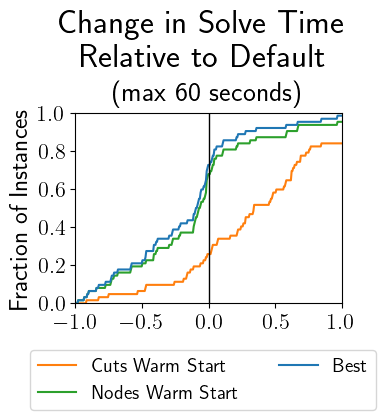

In [129]:
# i think this is because the trees themselves aren't that big, so nodes warm start is a huge help
plot_distributions(time_df, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1), ylim=(0, 1), bins=350, relative=True, best=True, max_value=60)

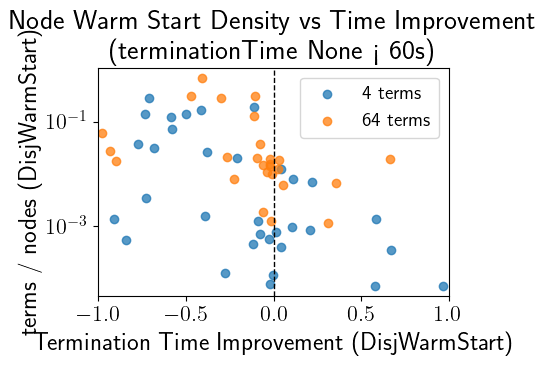

In [130]:
# plot comparing time_df["terminationTimeImprovement DisjWarmStart"] on the x axis and df["terms"] / df["nodes DisjWarmStart"] on the y axis where time_df["terminationTime None"] < 60
# filter rows
mask = time_df["terminationTime None"] < 60


base = time_df.loc[mask, "terminationTime None"]
s = time_df.loc[mask, "terminationTime DisjWarmStart"]
x = -(base - s) / base
y = time_df.loc[mask, "terms"] / time_df.loc[mask, "nodes DisjWarmStart"]

# drop NaNs / infs just in case
valid = x.notna() & y.notna() & np.isfinite(y)
x = x[valid]
y = y[valid]

plt.figure(figsize=(5, 4))
# binary coloring
colors = {4: "tab:blue", 64: "tab:orange"}
for t in sorted(colors):
    idx = df["terms"] == t
    if idx.any():
        plt.scatter(x[idx], y[idx], color=colors[t], label=f"{t} terms", alpha=0.75)

plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Termination Time Improvement (DisjWarmStart)")
plt.ylabel("terms / nodes (DisjWarmStart)")
plt.yscale("log")
plt.xlim(-1, 1)
plt.title("Node Warm Start Density vs Time Improvement\n(terminationTime None < 60s)")
plt.legend(frameon=True)

plt.tight_layout()
plt.show()


0.10323886639676114


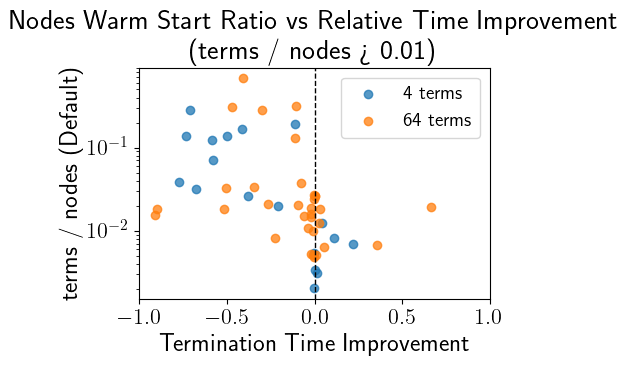

In [131]:
# -------------------------
# Build mask
# -------------------------
density = time_df["terms"] / time_df["nodes None"]

mask = (
    (density > 0.005)
    & time_df["terminationTime None"].notna()
    & time_df["terminationTime DisjWarmStart"].notna()
    & time_df["nodes DisjWarmStart"].notna()
)

print(sum(mask) / len(time_df))

df_filt = time_df.loc[mask].copy()

# -------------------------
# Build x and y
# -------------------------
base = df_filt["terminationTime None"]
s = df_filt["terminationTime DisjWarmStart"]

x = -(base - s) / base
y = df_filt["terms"] / df_filt["nodes DisjWarmStart"]
terms = df_filt["terms"].values  # for coloring

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(5, 4))

colors = {4: "tab:blue", 64: "tab:orange"}

for t in sorted(colors):
    idx = (terms == t)
    if idx.any():
        plt.scatter(
            x[idx],
            y[idx],
            color=colors[t],
            label=f"{t} terms",
            alpha=0.75,
        )

plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.xlim(-1, 1)
plt.yscale("log")

plt.xlabel("Termination Time Improvement")
plt.ylabel("terms / nodes (Default)")
plt.title("Nodes Warm Start Ratio vs Relative Time Improvement\n(terms / nodes > 0.01)")

plt.legend()
plt.tight_layout()
plt.show()

# we see reliable improvements when terms/nodes is > 1% - makes sense, this is a significant head start

62  rows after filtering


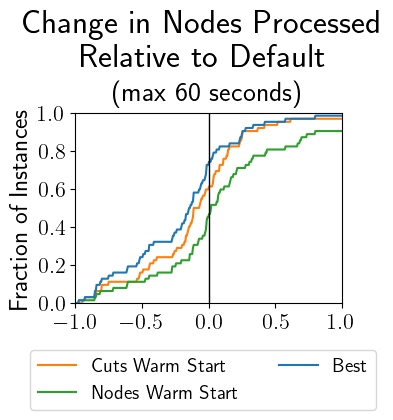

In [132]:
# not surprising to see cuts edge up - we know they do a good job of reducing nodes, but density slows down iteration speed
# i would assume fewer LP iterations per node as you go deeper into the tree (ie each branching decision should need fewer iterations to reoptimize since problems already well restricted)
# which is why you see nodes and iterations go down in wins but perform better in time since we get to start deeper in the tree
plot_distributions(time_df, "nodes", ["None", "NoDisjunction", "DisjWarmStart"],
                   xlim=(-1, 1), ylim=(0, 1), bins=350, relative=True,
                   best=True, max_value=60)

62  rows after filtering


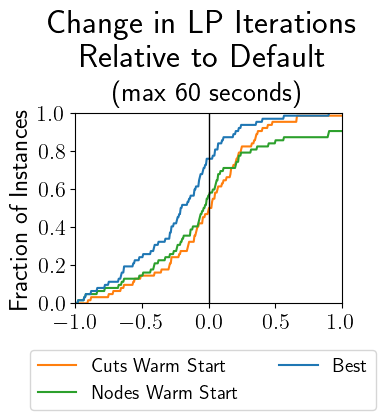

In [133]:
# does time per pivot go down? just show that, time per iteration as function of depth
# also check with sparsity of matrix vs iteration time
plot_distributions(time_df, "iterations", ["None", "NoDisjunction", "DisjWarmStart"],
                   xlim=(-1, 1), ylim=(0, 1), bins=350,
                   relative=True, best=True, max_value=60)

In [134]:
# now limit to instances where at least one generator solved to optimality 
mask = (
    (df["Disjunction (Cuts)"] < 0.9999) & (df["instanceIndex"] > 0) & (df["terminationTime None"] > 5)
    & np.logical_or.reduce([(optimality_gap(df, gen) <= 1e-4) for gen in generators])
)
time_df2 = df.loc[mask, group_cols + id_cols + fields]

44  rows after filtering


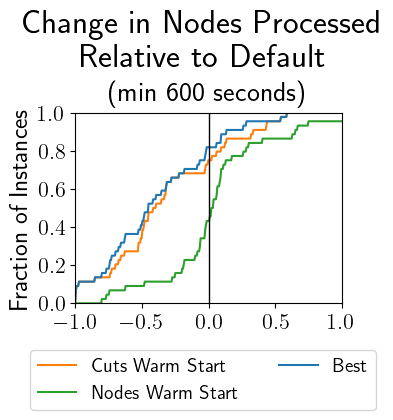

In [136]:
# filter with logical_or.reduce to get instances where at least one generator solved to optimality, which reveals a pretty clear trend towards using cuts
# expected - pdcs trim tree at root reducing overall size
# the fact that most warm start methods are solving to optimality means improvements are not due to increases in time per iteration that are cancelled out by time capped runs
plot_distributions(time_df2, "nodes", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1), ylim=(0, 1), bins=350, relative=True, best=True, min_value=600)

44  rows after filtering


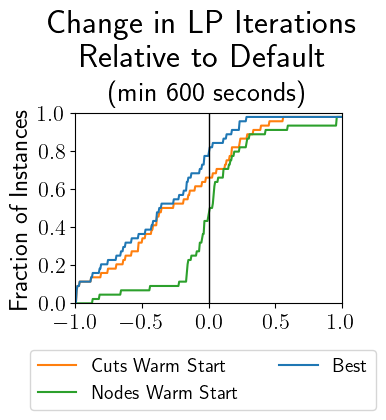

In [137]:
# smaller tree means fewer iterations, but weak relationship with time improvements because of cut density
plot_distributions(time_df2, "iterations", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1), ylim=(0, 1), bins=350, relative=True, best=True, min_value=600)

In [147]:
def plot_distributions(
    histogram_df, feature, compare_gens, bins=100, xlim=(-2, 1), ylim=(0, 1),
    perturbation=None, exclude_perturbation=False, title_x=.525, relative=True, best=False,
    fill=False, min_value=None, max_value=None, gap_tol=1e-4
):

    base_gen = compare_gens[0]

    # -----------------------------
    # Filters
    # -----------------------------
    def apply_filters(df_):
        if perturbation is not None:
            df_ = (
                df_[df_["perturbation"] == perturbation]
                if not exclude_perturbation
                else df_[df_["perturbation"] != perturbation]
            )

        base_col = f"{feature} None"
        if base_col in df_.columns:
            if min_value is not None:
                df_ = df_[df_[base_col] >= min_value]
            if max_value is not None:
                df_ = df_[df_[base_col] <= max_value]

        return df_

    df = apply_filters(histogram_df.copy())
    n_total = len(df)
    if n_total == 0:
        print("No rows after filtering; nothing to plot.")
        return

    x_grid = np.linspace(xlim[0], xlim[1], bins)

    def cdf_y(series):
        s = series
        return np.array([(s <= v).sum() / len(s) for v in x_grid])

    cmap = plt.get_cmap("tab10")

    # -----------------------------
    # Build LEFT (time metric) per-gen on rows where that gen is optimal
    # -----------------------------
    metric_cdfs = {}
    opt_fracs = {}  # p_opt per gen (fraction of all filtered rows)
    for gen in compare_gens[1:]:
        gap_col = f"gap {gen}"
        base_col = f"{feature} {base_gen}"
        gen_col = f"{feature} {gen}"

        if gap_col not in df.columns or base_col not in df.columns or gen_col not in df.columns:
            continue

        opt_mask = df[gap_col].notna() & (df[gap_col] <= gap_tol)
        opt_fracs[gen] = opt_mask.mean()

        if opt_mask.sum() <= 1:
            continue

        base = df.loc[opt_mask, base_col]
        s = df.loc[opt_mask, gen_col]

        series = (-(base - s) / base) if relative else s
        series = series.replace([np.inf, -np.inf], np.nan).dropna()
        if series.notna().sum() > 1:
            metric_cdfs[gen] = cdf_y(series)

    # Optional "Best" on LEFT: best over compare_gens[1:] on rows where at least one of them is optimal
    if best:
        gap_cols = [f"gap {g}" for g in compare_gens[1:] if f"gap {g}" in df.columns]
        metric_cols = [f"{feature} {g}" for g in compare_gens[1:] if f"{feature} {g}" in df.columns]
        base_col = f"{feature} {base_gen}"

        if gap_cols and metric_cols and base_col in df.columns:
            opt_any = df[gap_cols].le(gap_tol).any(axis=1) & df[gap_cols].notna().any(axis=1)
            opt_fracs["Best"] = opt_any.mean()

            if opt_any.sum() > 1:
                best_metric = df.loc[opt_any, metric_cols].min(axis=1)
                base = df.loc[opt_any, base_col]
                series = (-(base - best_metric) / base) if relative else best_metric
                series = series.replace([np.inf, -np.inf], np.nan).dropna()
                if series.notna().sum() > 1:
                    metric_cdfs["Best"] = cdf_y(series)

    # -----------------------------
    # Global masks for stacking
    # -----------------------------
    gap_cols_all = [f"gap {g}" for g in compare_gens[1:] if f"gap {g}" in df.columns]
    any_opt = None
    if gap_cols_all:
        any_opt = df[gap_cols_all].le(gap_tol).any(axis=1) & df[gap_cols_all].notna().any(axis=1)

    # Right-panel mask: NONE of the compared generators are optimal, and gaps are present for all
    none_opt_mask = None
    base_gap_col = f"gap {base_gen}"
    if gap_cols_all and base_gap_col in df.columns:
        base_gap_all = df[base_gap_col]
        none_opt_mask = (
            df[gap_cols_all].notna().all(axis=1)
            & df[gap_cols_all].gt(gap_tol).all(axis=1)
            & base_gap_all.notna()
        )

    p_opt_global = float(any_opt.mean()) if any_opt is not None else 0.0
    p_not_global = float(none_opt_mask.mean()) if none_opt_mask is not None else (1.0 - p_opt_global)

    # -----------------------------
    # Build RIGHT (gap closed) on the shared "none_opt_mask"
    # This guarantees Best is the topmost curve in the right panel.
    # -----------------------------
    gap_cdfs = {}
    if none_opt_mask is not None and none_opt_mask.sum() > 1:
        base_gap_all = df[base_gap_col]
        base_gap = base_gap_all.loc[none_opt_mask].replace(0, np.nan)

        # Per-generator curves on the same rows
        for gen in compare_gens[1:]:
            gap_col = f"gap {gen}"
            if gap_col not in df.columns:
                continue

            g_gap = df.loc[none_opt_mask, gap_col]
            series = -(base_gap - g_gap) / base_gap
            series = series.replace([np.inf, -np.inf], np.nan).dropna()
            if series.notna().sum() > 1:
                gap_cdfs[gen] = cdf_y(series)

        # Best curve on the same rows
        if best:
            best_gap = df.loc[none_opt_mask, gap_cols_all].min(axis=1)
            series = -(base_gap - best_gap) / base_gap
            series = series.replace([np.inf, -np.inf], np.nan).dropna()
            if series.notna().sum() > 1:
                gap_cdfs["Best"] = cdf_y(series)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    # Left panel
    for g, y in metric_cdfs.items():
        axL.plot(
            x_grid, p_opt_global * y,
            label=cat_map.get(g, g),
            color=cmap(generators.index(g) if ("generators" in globals() and g in generators) else 0),
        )
    if relative:
        axL.axvline(0, color="black", linewidth=1)
    axL.set_xlim(xlim)
    axL.set_ylim(ylim)
    axL.set_ylabel("Fraction of Instances")
    axL.set_yticks(np.arange(0, 1.01, 0.2))
    axL.set_xlabel("Relative Change in Solve Time" if relative else "Value")
    axL.set_title(rf"Gap $\leq$ {gap_tol:.0e}")

    # Right panel
    for g, y in gap_cdfs.items():
        axR.plot(
            x_grid, p_opt_global + p_not_global * y,
            label=cat_map.get(g, g),
            color=cmap(generators.index(g) if ("generators" in globals() and g in generators) else 0),
        )
    axR.axvline(0, color="black", linewidth=1)
    axR.set_xlim(xlim)
    axR.set_ylim(ylim)
    axR.set_xlabel("Relative Change in Gap Closed")
    axR.set_title(rf"Gap $>$ {gap_tol:.0e}")

    # Legend (shared)
    hL, lL = axL.get_legend_handles_labels()
    hR, lR = axR.get_legend_handles_labels()
    seen = set()
    handles, labels_ = [], []
    for h, lab in list(zip(hL, lL)) + list(zip(hR, lR)):
        if lab not in seen:
            seen.add(lab)
            handles.append(h)
            labels_.append(lab)

    fig.legend(handles, labels_, loc="lower center", bbox_to_anchor=(title_x, -0.075), ncol=3)

    fig.suptitle(
        f"{'Change in ' if relative else ''}Solve Performance"
        f"{'for ' + (perturbation.title() if perturbation != 'rhs' else perturbation.upper()) + ' Perturbations' if perturbation else ''}"
        f" Relative to {cat_map.get(base_gen, base_gen)}\n(min 600 seconds)",
        x=title_x, y=.9
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            out_fldr,
            f"cdf_{feature}{'_' + perturbation if perturbation else ''}"
            f"{'_relative_improvements_' + base_gen if relative else ''}"
            f"{'_best' if best else ''}"
            f"{'_twopanel_opt_gap'}.png"
        ),
        dpi=1200,
        bbox_inches="tight",
    )
    plt.show()



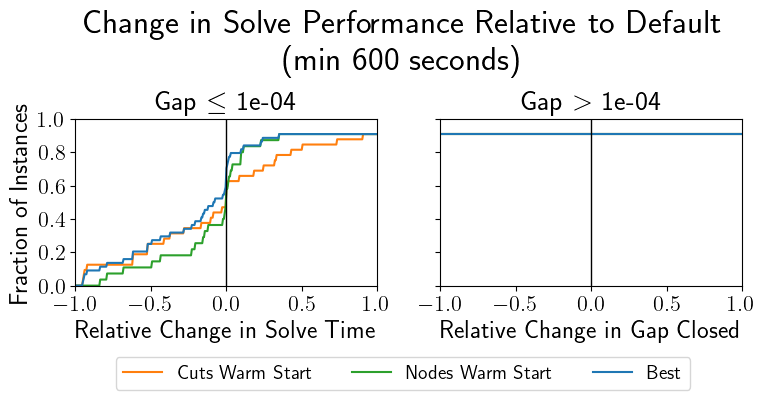

In [148]:
# filter with logical_or.reduce to get instances where at least one generator solved to optimality, which reveals a pretty clear trend towards using cuts
# makes sense that nodes warm start is less variant because small disjunctions don't really change overall look of tree
# however, dense cuts can really weigh us down if they get held deep into the tree, but help give advantage of shrunken tree if phased out early
plot_distributions(time_df2, "terminationTime", ["None", "NoDisjunction", "DisjWarmStart"], xlim=(-1, 1), ylim=(0, 1), bins=350, relative=True, best=True, min_value=600)